# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Maria Reina Zarate Nava

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

In [1]:
# Importamos la librería pandas para la manipulación de datos
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
# Cargamos el dataset en un DataFrame usando Pandas
dfSucio = pd.read_csv("../DataSet/ventas-por-factura.csv", encoding='utf-8')

In [6]:
# Renombrar columnas para simplificar su uso
dfSucio.columns = ['NoFactura', 'FechaFactura', 'IDCliente', 'Pais', 'Cantidad', 'Monto']

In [7]:
# Verificamos las dimensiones actuales del dataset (filas y columnas)
dfSucio.shape

(25953, 6)

In [8]:
# Visualizamos las primeras filas para inspeccionar la estructura de los datos
dfSucio.head()

,NoFactura,FechaFactura,IDCliente,Pais,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [9]:
dfSucio.tail()

,NoFactura,FechaFactura,IDCliente,Pais,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [10]:
# Calculamos estadísticas descriptivas básicas (media, min, max, etc.)
dfSucio.describe()

,IDCliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [11]:
# Obtenemos un resumen de las columnas, tipos de datos y valores no nulos
dfSucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NoFactura     25953 non-null  str    
 1   FechaFactura  25953 non-null  str    
 2   IDCliente     22229 non-null  float64
 3   Pais          25953 non-null  str    
 4   Cantidad      25953 non-null  int64  
 5   Monto         25953 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.2 MB


In [12]:
dfSucio.dtypes

NoFactura           str
FechaFactura        str
IDCliente       float64
Pais                str
Cantidad          int64
Monto               str
dtype: object

## 1. Valores Nulos

In [13]:
dfSucio.isnull().sum()

NoFactura          0
FechaFactura       0
IDCliente       3724
Pais               0
Cantidad           0
Monto              0
dtype: int64

In [14]:
dfSucio = dfSucio.dropna(subset=['IDCliente'])

In [15]:
dfSucio.isnull().sum()

NoFactura       0
FechaFactura    0
IDCliente       0
Pais            0
Cantidad        0
Monto           0
dtype: int64

## 2. Problemas de formato o tipo de datos

In [16]:
dfSucio["Monto"] = dfSucio["Monto"].str.replace(',', '.').astype(float)

In [17]:
dfSucio["FechaFactura"] = pd.to_datetime(dfSucio["FechaFactura"], format='mixed')

In [18]:
dfSucio["IDCliente"] = dfSucio["IDCliente"].astype(int)

In [19]:
dfSucio.dtypes

NoFactura                  str
FechaFactura    datetime64[us]
IDCliente                int64
Pais                       str
Cantidad                 int64
Monto                  float64
dtype: object

## 3. Facturas canceladas (identificadas con la letra C)

In [20]:
dfSucio["NoFactura"] = dfSucio["NoFactura"].astype(str)
dfSucio[dfSucio["NoFactura"].str.startswith("C")]

,NoFactura,FechaFactura,IDCliente,Pais,Cantidad,Monto
2,C570727,2021-10-12 11:32:00,12471,Germany,-1,-1.45
10,C543628,2021-02-10 15:51:00,16558,United Kingdom,-5,-9.25
17,C553508,2021-05-17 13:44:00,14000,United Kingdom,-3,-1.95
20,C577693,2021-11-21 11:48:00,12628,Germany,-3,-16.85
22,C547309,2021-03-22 11:17:00,17416,United Kingdom,-12,-45.00
...,...,...,...,...,...,...
25936,C542910,2021-02-01 15:38:00,17511,United Kingdom,-15,-61.10
25943,C557061,2021-06-16 14:55:00,14895,United Kingdom,-5,-14.75
25944,C562147,2021-08-03 10:47:00,16180,United Kingdom,-7,-18.35
25947,C553519,2021-05-17 14:16:00,18218,United Kingdom,-2,-9.90


In [21]:
facturas_canceladas = dfSucio["NoFactura"].str.startswith("C")
dfSucio = dfSucio[~facturas_canceladas]

In [22]:
# Verificamos las dimensiones actuales del dataset (filas y columnas)
dfSucio.shape

(18570, 6)

## 4. Outliers (Negativos o fuera de rango) y Datos invalidos

In [23]:
dfSucio[dfSucio["Cantidad"] <= 0]

,NoFactura,FechaFactura,IDCliente,Pais,Cantidad,Monto


In [24]:
dfSucio[dfSucio["Monto"] <= 0]

,NoFactura,FechaFactura,IDCliente,Pais,Cantidad,Monto
3668,564651,2021-08-26 14:19:00,14646,Netherlands,576,0.0
4752,543599,2021-02-10 13:08:00,17560,United Kingdom,16,0.0
12491,578841,2021-11-25 15:57:00,13256,United Kingdom,12540,0.0
15195,568384,2021-09-27 09:46:00,12748,United Kingdom,1,0.0
15861,568384,2021-09-27 09:46:00,12748,United Kingdom,1,0.0


In [25]:
dfSucio = dfSucio[(dfSucio["Cantidad"] > 0) & (dfSucio["Monto"] > 0)]

In [26]:
# Verificamos las dimensiones actuales del dataset (filas y columnas)
dfSucio.shape

(18565, 6)

## 5. Duplicados

In [27]:
dfSucio.duplicated().sum()

np.int64(3)

In [28]:
dfSucio = dfSucio.drop_duplicates()

In [29]:
# Verificamos las dimensiones actuales del dataset (filas y columnas)
dfSucio.shape

(18562, 6)

## Graficas solicitadas
### 1. Ventas por pais

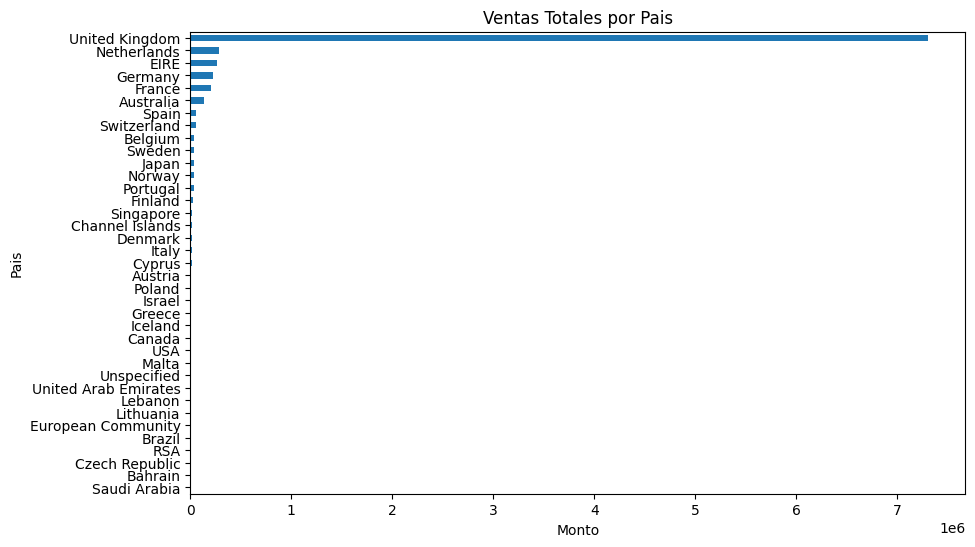

In [30]:
ventas_pais = dfSucio.groupby('Pais')['Monto'].sum().sort_values()
ventas_pais.plot(kind='barh', figsize=(10, 6))
plt.title('Ventas Totales por Pais')
plt.xlabel('Monto')
plt.ylabel('Pais')
plt.show()

### 2. Heatmap de valores nulos

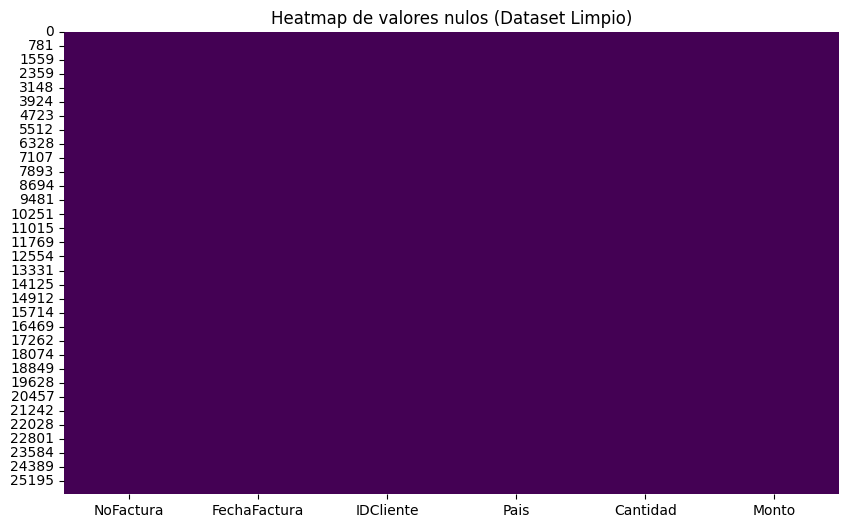

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(dfSucio.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap de valores nulos (Dataset Limpio)')
plt.show()

### 3. Distribucion del monto

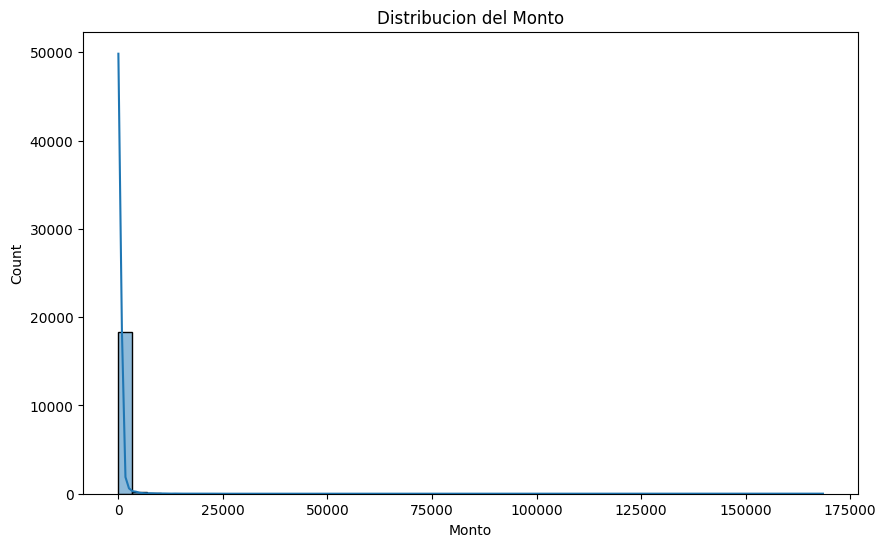

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(dfSucio['Monto'], bins=50, kde=True)
plt.title('Distribucion del Monto')
plt.show()

## Exportar dataset limpio

In [33]:
dfSucio.to_csv("Data_Limpio_Factura.csv", index=False)

# Conclusiones y Principio GIGO

El principio **GIGO (Garbage In, Garbage Out)** establece que la calidad de los resultados de un análisis o modelo de Machine Learning depende enteramente de la calidad de los datos de entrada. Si ingresamos datos "basura" (sucios o erróneos), los resultados también serán basura.

En esta práctica identificamos y corregimos los siguientes problemas que hubieran afectado negativamente cualquier modelo:

1. **Valores nulos**: Se eliminaron registros sin ID de cliente, ya que no sirven para análisis de segmentación.
2. **Formatos incorrectos**: El monto tenía comas en lugar de puntos decimales, impidiendo operaciones matemáticas.
3. **Tipos de datos**: Fechas como texto e ID de clientes como flotantes fueron corregidos.
4. **Facturas canceladas (C)**: Se eliminaron porque incluirlas hubiera inflado irrealmente los ingresos totales.
5. **Outliers e Inválidos**: Se descartaron cantidades y montos negativos o en cero, que hubieran sesgado las distribuciones de los modelos.
6. **Duplicados**: Se eliminaron filas repetidas para evitar doble conteo.